In [11]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
import optuna


In [12]:
df = pd.read_csv('../Milestone 3 EDA/ibm_hi_small_trans_cleaned.csv')
df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Amount Paid,Is Laundering,Amount_Received_USD,Amount_Paid_USD,...,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.340000,3697.340000,0,3697.340000,3697.340000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.010000,0.010000,0,0.010000,0.010000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.570000,14675.570000,0,14675.570000,14675.570000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.970000,2806.970000,0,2806.970000,2806.970000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.970000,36682.970000,0,36682.970000,36682.970000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0.154978,0.154978,0,3107.386389,3107.386389,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0.108128,0.108128,0,2168.020464,2168.020464,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0.004988,0.004988,0,100.011894,100.011894,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0.038417,0.038417,0,770.280058,770.280058,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,1


In [13]:
df.columns

Index(['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1',
       'Amount Received', 'Amount Paid', 'Is Laundering',
       'Amount_Received_USD', 'Amount_Paid_USD',
       ...
       'Payment Currency_Yuan', 'Payment Format_ACH', 'Payment Format_Bitcoin',
       'Payment Format_Cash', 'Payment Format_Cheque',
       'Payment Format_Credit Card', 'Payment Format_Reinvestment',
       'Payment Format_Wire', 'Account_Same', 'Bank_Same'],
      dtype='object', length=109)

In [14]:
df.drop(columns=['Timestamp', 'From Bank', 'To Bank', 'Account', 'Account.1'], inplace=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Columns: 104 entries, Amount Received to Bank_Same
dtypes: float64(101), int64(3)
memory usage: 3.9 GB


In [16]:
random_state = 42

## Baseline Model on Entire Dataset

In [17]:
X = df.drop(columns='Is Laundering')
y = df['Is Laundering']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    stratify=y,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

### Default settings on RF

In [19]:
# Train using optimal parameters
model = RandomForestClassifier(
    random_state=random_state,
    n_jobs=-1,
)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
y_pred = model.predict(X_test)

In [21]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1014634
           1       0.13      0.08      0.10      1035

    accuracy                           1.00   1015669
   macro avg       0.57      0.54      0.55   1015669
weighted avg       1.00      1.00      1.00   1015669



In [22]:
baseline_model_report_df = classification_report(y_test, y_pred, output_dict=True)

### Class Weight Balanced

In [23]:
# Train using optimal parameters
model = RandomForestClassifier(
    class_weight='balanced',
    random_state=random_state,
    n_jobs=-1
)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
y_pred = model.predict(X_test)

In [25]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1014634
           1       0.05      0.08      0.06      1035

    accuracy                           1.00   1015669
   macro avg       0.53      0.54      0.53   1015669
weighted avg       1.00      1.00      1.00   1015669



In [26]:
baseline_balanced_model_report_df = classification_report(y_test, y_pred, output_dict=True)

## Undersampling due to Class Imbalance

In [27]:
fraud = df[df['Is Laundering'] == 1]
non_fraud = df[df['Is Laundering'] == 0]
len(fraud), len(non_fraud)

(5177, 5073168)

In [28]:
# Undersample majority class to a 1:10 ratio
non_fraud_downsampled = non_fraud.sample(n=len(fraud) * 10, random_state=random_state)
non_fraud_downsampled

,Amount Received,Amount Paid,Is Laundering,Amount_Received_USD,Amount_Paid_USD,US Dollar_Amount_Paid_Mean,US Dollar_Amount_Paid_Median,US Dollar_Amount_Received_Mean,US Dollar_Amount_Received_Median,Bitcoin_Amount_Paid_Mean,...,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
4563287,1439.79,1439.79,0,3.829841e+02,3.829841e+02,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0
4216770,33.09,33.09,0,3.309000e+01,3.309000e+01,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0
2992877,263.34,263.34,0,3.807896e+01,3.807896e+01,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1499016,17154983.76,17154983.76,0,1.747064e+07,1.747064e+07,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
510282,8499.22,8499.22,0,2.501320e+03,2.501320e+03,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3992741,5722.87,5722.87,0,5.722870e+03,5.722870e+03,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
44465,82208.92,82208.92,0,8.220892e+04,8.220892e+04,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0
1173046,6837.09,6837.09,0,5.196872e+03,5.196872e+03,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0
4125810,3261.27,3261.27,0,3.763506e+03,3.763506e+03,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0


In [29]:
# Combine and shuffle
df_reduced = pd.concat([fraud, non_fraud_downsampled]).sample(frac=1).reset_index(drop=True)
df_reduced

,Amount Received,Amount Paid,Is Laundering,Amount_Received_USD,Amount_Paid_USD,US Dollar_Amount_Paid_Mean,US Dollar_Amount_Paid_Median,US Dollar_Amount_Received_Mean,US Dollar_Amount_Received_Median,Bitcoin_Amount_Paid_Mean,...,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
0,128.42,128.42,0,127.713690,127.713690,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0
1,545.08,545.08,0,545.080000,545.080000,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
2,2720.31,2720.31,0,45.157146,45.157146,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1
3,726.25,726.25,0,726.250000,726.250000,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,989.33,989.33,0,989.330000,989.330000,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56942,59.80,59.80,0,59.800000,59.800000,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
56943,205919.41,205919.41,0,205919.410000,205919.410000,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
56944,91636.28,91636.28,0,1521.162248,1521.162248,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
56945,29.16,29.16,0,29.160000,29.160000,367153.780541,904.13,4.041979e+06,908.2,20.809275,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0


In [30]:
X = df_reduced.drop(columns='Is Laundering')
y = df_reduced['Is Laundering']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    stratify=y,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

In [32]:
# cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)
from sklearn.model_selection import StratifiedKFold


cv = StratifiedKFold(n_splits=5)

### RF With unscaled Data and recall as param tuning metric

In [33]:
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 10, 200)
    max_depth = trial.suggest_int("max_depth", 2, 32, log=True)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    
    model = RandomForestClassifier(
        class_weight='balanced',
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train, 
        y=y_train, 
        cv=cv,
        scoring='recall',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

unscaled_df = study.trials_dataframe().sort_values("value", ascending=False)
top_5_unscaled_df = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_unscaled_df)

[I 2026-04-15 10:54:46,643] A new study created in memory with name: no-name-ac8b26f8-e9ca-41dd-b4b8-fe7dda14a9b0
[I 2026-04-15 10:54:53,608] Trial 0 finished with value: 0.8145842438652003 and parameters: {'n_estimators': 194, 'max_depth': 17, 'min_samples_split': 7}. Best is trial 0 with value: 0.8145842438652003.
[I 2026-04-15 10:54:55,645] Trial 1 finished with value: 0.8408964295495999 and parameters: {'n_estimators': 49, 'max_depth': 9, 'min_samples_split': 5}. Best is trial 1 with value: 0.8408964295495999.
[I 2026-04-15 10:54:58,704] Trial 2 finished with value: 0.8399293718641283 and parameters: {'n_estimators': 188, 'max_depth': 5, 'min_samples_split': 8}. Best is trial 1 with value: 0.8408964295495999.
[I 2026-04-15 10:55:02,694] Trial 3 finished with value: 0.7720946020757212 and parameters: {'n_estimators': 98, 'max_depth': 27, 'min_samples_split': 10}. Best is trial 1 with value: 0.8408964295495999.
[I 2026-04-15 10:55:06,519] Trial 4 finished with value: 0.75664178365180

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_min_samples_split,params_n_estimators,state
15,15,0.847657,2026-04-15 10:55:27.889589,2026-04-15 10:55:30.876821,0 days 00:00:02.987232,8,9,200,COMPLETE
86,86,0.847657,2026-04-15 10:58:40.219624,2026-04-15 10:58:43.199831,0 days 00:00:02.980207,8,9,200,COMPLETE
63,63,0.847415,2026-04-15 10:57:42.485952,2026-04-15 10:57:45.414648,0 days 00:00:02.928696,8,6,195,COMPLETE
52,52,0.846933,2026-04-15 10:57:08.461377,2026-04-15 10:57:11.409421,0 days 00:00:02.948044,8,5,200,COMPLETE
45,45,0.846933,2026-04-15 10:56:49.034211,2026-04-15 10:56:51.684057,0 days 00:00:02.649846,8,5,181,COMPLETE


In [34]:
top_5_unscaled_df

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_min_samples_split,params_n_estimators,state
15,15,0.847657,2026-04-15 10:55:27.889589,2026-04-15 10:55:30.876821,0 days 00:00:02.987232,8,9,200,COMPLETE
86,86,0.847657,2026-04-15 10:58:40.219624,2026-04-15 10:58:43.199831,0 days 00:00:02.980207,8,9,200,COMPLETE
63,63,0.847415,2026-04-15 10:57:42.485952,2026-04-15 10:57:45.414648,0 days 00:00:02.928696,8,6,195,COMPLETE
52,52,0.846933,2026-04-15 10:57:08.461377,2026-04-15 10:57:11.409421,0 days 00:00:02.948044,8,5,200,COMPLETE
45,45,0.846933,2026-04-15 10:56:49.034211,2026-04-15 10:56:51.684057,0 days 00:00:02.649846,8,5,181,COMPLETE


In [35]:
unscaled_df

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_min_samples_split,params_n_estimators,state
15,15,0.847657,2026-04-15 10:55:27.889589,2026-04-15 10:55:30.876821,0 days 00:00:02.987232,8,9,200,COMPLETE
86,86,0.847657,2026-04-15 10:58:40.219624,2026-04-15 10:58:43.199831,0 days 00:00:02.980207,8,9,200,COMPLETE
63,63,0.847415,2026-04-15 10:57:42.485952,2026-04-15 10:57:45.414648,0 days 00:00:02.928696,8,6,195,COMPLETE
52,52,0.846933,2026-04-15 10:57:08.461377,2026-04-15 10:57:11.409421,0 days 00:00:02.948044,8,5,200,COMPLETE
45,45,0.846933,2026-04-15 10:56:49.034211,2026-04-15 10:56:51.684057,0 days 00:00:02.649846,8,5,181,COMPLETE
...,...,...,...,...,...,...,...,...,...
23,23,0.792858,2026-04-15 10:55:47.621943,2026-04-15 10:55:53.811521,0 days 00:00:06.189578,21,8,185,COMPLETE
3,3,0.772095,2026-04-15 10:54:58.706529,2026-04-15 10:55:02.694692,0 days 00:00:03.988163,27,10,98,COMPLETE
58,58,0.760990,2026-04-15 10:57:26.384630,2026-04-15 10:57:31.994443,0 days 00:00:05.609813,32,10,181,COMPLETE
4,4,0.756642,2026-04-15 10:55:02.695692,2026-04-15 10:55:06.519831,0 days 00:00:03.824139,27,8,124,COMPLETE


In [36]:
# Train using optimal parameters
model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=top_5_unscaled_df.head(1)['params_n_estimators'].item(),
    max_depth=top_5_unscaled_df.head(1)['params_max_depth'].item(),
    min_samples_split=top_5_unscaled_df.head(1)['params_min_samples_split'].item(),
    random_state=random_state
)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,8
,min_samples_split,9
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
y_pred = model.predict(X_test)

In [38]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.99      0.92      0.95     10355
           1       0.54      0.88      0.67      1035

    accuracy                           0.92     11390
   macro avg       0.76      0.90      0.81     11390
weighted avg       0.95      0.92      0.93     11390



In [39]:
recall_model_report_df = classification_report(y_test, y_pred, output_dict=True)

### No scaling, f1 as eval metric

In [40]:
# Parameter tuning
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score


def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 10, 200)
    max_depth = trial.suggest_int("max_depth", 2, 32, log=True)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    
    model = RandomForestClassifier(
        class_weight='balanced',
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train, 
        y=y_train, 
        cv=cv,
        scoring="f1",
        n_jobs=-1,
    )
    f1 = scores.mean()
    return f1


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

f1_df = study.trials_dataframe().sort_values("value", ascending=False)
top_5_f1_df = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_f1_df)

[I 2026-04-15 10:59:25,455] A new study created in memory with name: no-name-e870bdfa-0812-4e81-a10a-a1908487061e
[I 2026-04-15 10:59:27,382] Trial 0 finished with value: 0.6596926152088642 and parameters: {'n_estimators': 100, 'max_depth': 8, 'min_samples_split': 9}. Best is trial 0 with value: 0.6596926152088642.
[I 2026-04-15 10:59:32,232] Trial 1 finished with value: 0.6842852566151353 and parameters: {'n_estimators': 171, 'max_depth': 14, 'min_samples_split': 9}. Best is trial 1 with value: 0.6842852566151353.
[I 2026-04-15 10:59:33,381] Trial 2 finished with value: 0.6448318028250111 and parameters: {'n_estimators': 146, 'max_depth': 2, 'min_samples_split': 4}. Best is trial 1 with value: 0.6842852566151353.
[I 2026-04-15 10:59:35,352] Trial 3 finished with value: 0.6618878599327725 and parameters: {'n_estimators': 131, 'max_depth': 6, 'min_samples_split': 7}. Best is trial 1 with value: 0.6842852566151353.
[I 2026-04-15 10:59:36,358] Trial 4 finished with value: 0.66238662899165

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_min_samples_split,params_n_estimators,state
72,72,0.693252,2026-04-15 11:03:50.486086,2026-04-15 11:03:55.058310,0 days 00:00:04.572224,17,3,178,COMPLETE
65,65,0.693085,2026-04-15 11:03:15.829597,2026-04-15 11:03:20.813621,0 days 00:00:04.984024,17,3,195,COMPLETE
98,98,0.693025,2026-04-15 11:05:49.846198,2026-04-15 11:05:55.682824,0 days 00:00:05.836626,17,2,183,COMPLETE
99,99,0.693025,2026-04-15 11:05:55.684832,2026-04-15 11:06:01.590916,0 days 00:00:05.906084,17,2,183,COMPLETE
83,83,0.692825,2026-04-15 11:04:40.553966,2026-04-15 11:04:45.625790,0 days 00:00:05.071824,17,2,175,COMPLETE


In [41]:
f1_df

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_min_samples_split,params_n_estimators,state
72,72,0.693252,2026-04-15 11:03:50.486086,2026-04-15 11:03:55.058310,0 days 00:00:04.572224,17,3,178,COMPLETE
65,65,0.693085,2026-04-15 11:03:15.829597,2026-04-15 11:03:20.813621,0 days 00:00:04.984024,17,3,195,COMPLETE
98,98,0.693025,2026-04-15 11:05:49.846198,2026-04-15 11:05:55.682824,0 days 00:00:05.836626,17,2,183,COMPLETE
99,99,0.693025,2026-04-15 11:05:55.684832,2026-04-15 11:06:01.590916,0 days 00:00:05.906084,17,2,183,COMPLETE
83,83,0.692825,2026-04-15 11:04:40.553966,2026-04-15 11:04:45.625790,0 days 00:00:05.071824,17,2,175,COMPLETE
...,...,...,...,...,...,...,...,...,...
69,69,0.638353,2026-04-15 11:03:36.055097,2026-04-15 11:03:41.453319,0 days 00:00:05.398222,26,2,162,COMPLETE
13,13,0.622654,2026-04-15 10:59:58.350827,2026-04-15 11:00:04.459868,0 days 00:00:06.109041,28,2,199,COMPLETE
44,44,0.619320,2026-04-15 11:02:01.072888,2026-04-15 11:02:05.876809,0 days 00:00:04.803921,31,3,158,COMPLETE
64,64,0.618366,2026-04-15 11:03:10.055980,2026-04-15 11:03:15.828599,0 days 00:00:05.772619,29,2,185,COMPLETE


In [42]:
# Train using optimal parameters
model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=top_5_f1_df.head(1)['params_n_estimators'].item(),
    max_depth=top_5_f1_df.head(1)['params_max_depth'].item(),
    min_samples_split=top_5_f1_df.head(1)['params_min_samples_split'].item(),
    random_state=random_state
)
model.fit(X_train, y_train)

,n_estimators,178
,criterion,'gini'
,max_depth,17
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
y_pred = model.predict(X_test)

In [44]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96     10355
           1       0.60      0.84      0.70      1035

    accuracy                           0.93     11390
   macro avg       0.79      0.89      0.83     11390
weighted avg       0.95      0.93      0.94     11390



In [45]:
f1_model_report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)

### Compare Models

In [46]:
# 2. Convert and transpose
recall_report_df = pd.DataFrame(recall_model_report_df).transpose()
f1_report_df = pd.DataFrame(f1_model_report).transpose()

# 3. Combine multiple reports (e.g., adding a 'Model' column for identification)
combined_df = pd.concat([recall_report_df, f1_report_df], keys=['IBM RF optimized for Recall', 'IBM RF optimized for F1'])

In [47]:
combined_df

precision    recall  f1-score  \
IBM RF optimized for Recall 0              0.986803  0.924288  0.954523   
                            1              0.536369  0.876329  0.665444   
                            accuracy       0.919930  0.919930  0.919930   
                            macro avg      0.761586  0.900308  0.809983   
                            weighted avg   0.945872  0.919930  0.928254   
IBM RF optimized for F1     0              0.983390  0.943409  0.962985   
                            1              0.597527  0.840580  0.698515   
                            accuracy       0.934065  0.934065  0.934065   
                            macro avg      0.790459  0.891994  0.830750   
                            weighted avg   0.948327  0.934065  0.938953   

                                               support  
IBM RF optimized for Recall 0             10355.000000  
                            1              1035.000000  
                            accuracy          0.919930  
                            macro avg     11390.000000  
                            weighted avg  11390.000000  
IBM RF optimized for F1     0             10355.000000  
                            1              1035.000000  
                            accuracy          0.934065  
                            macro avg     11390.000000  
                            weighted avg  11390.000000

In [48]:
model.feature_importances_

array([0.08200373, 0.08314775, 0.10094753, 0.11362342, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.00057622,
       0.00131767, 0.00060855, 0.00068345, 0.00187302, 0.00059657,
       0.00059819, 0.00056678, 0.00441966, 0.00102402, 0.00074

In [49]:
pd.set_option('display.max_rows', None)

In [50]:
importances = model.feature_importances_
feature_names = df.drop(columns='Is Laundering').columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values(
    'Gini Importance', ascending=False)
feature_imp_df

,Feature,Gini Importance
94,Payment Format_ACH,0.343775
3,Amount_Paid_USD,0.113623
2,Amount_Received_USD,0.100948
97,Payment Format_Cheque,0.096874
1,Amount Paid,0.083148
0,Amount Received,0.082004
98,Payment Format_Credit Card,0.059582
101,Account_Same,0.023844
96,Payment Format_Cash,0.019227
99,Payment Format_Reinvestment,0.017381


### Multivariate Analysis

In [54]:
"""
I need to explore the following important features:
Payment_Format_ACH 0.33
Amount_Paid_USD 0.12, 
Amount_Received_USD 0.11, 
Payment_Format_Cheque 0.09, 
Payment_Format_Credit_Card 0.06, 
Account_Same 0.03
"""
important_features = [
    'Payment Format_ACH',
    'Amount_Paid_USD',
    'Amount_Received_USD',
    'Payment Format_Cheque',
    'Payment Format_Credit Card',
    'Account_Same',
]

In [ ]:
import seaborn as sns

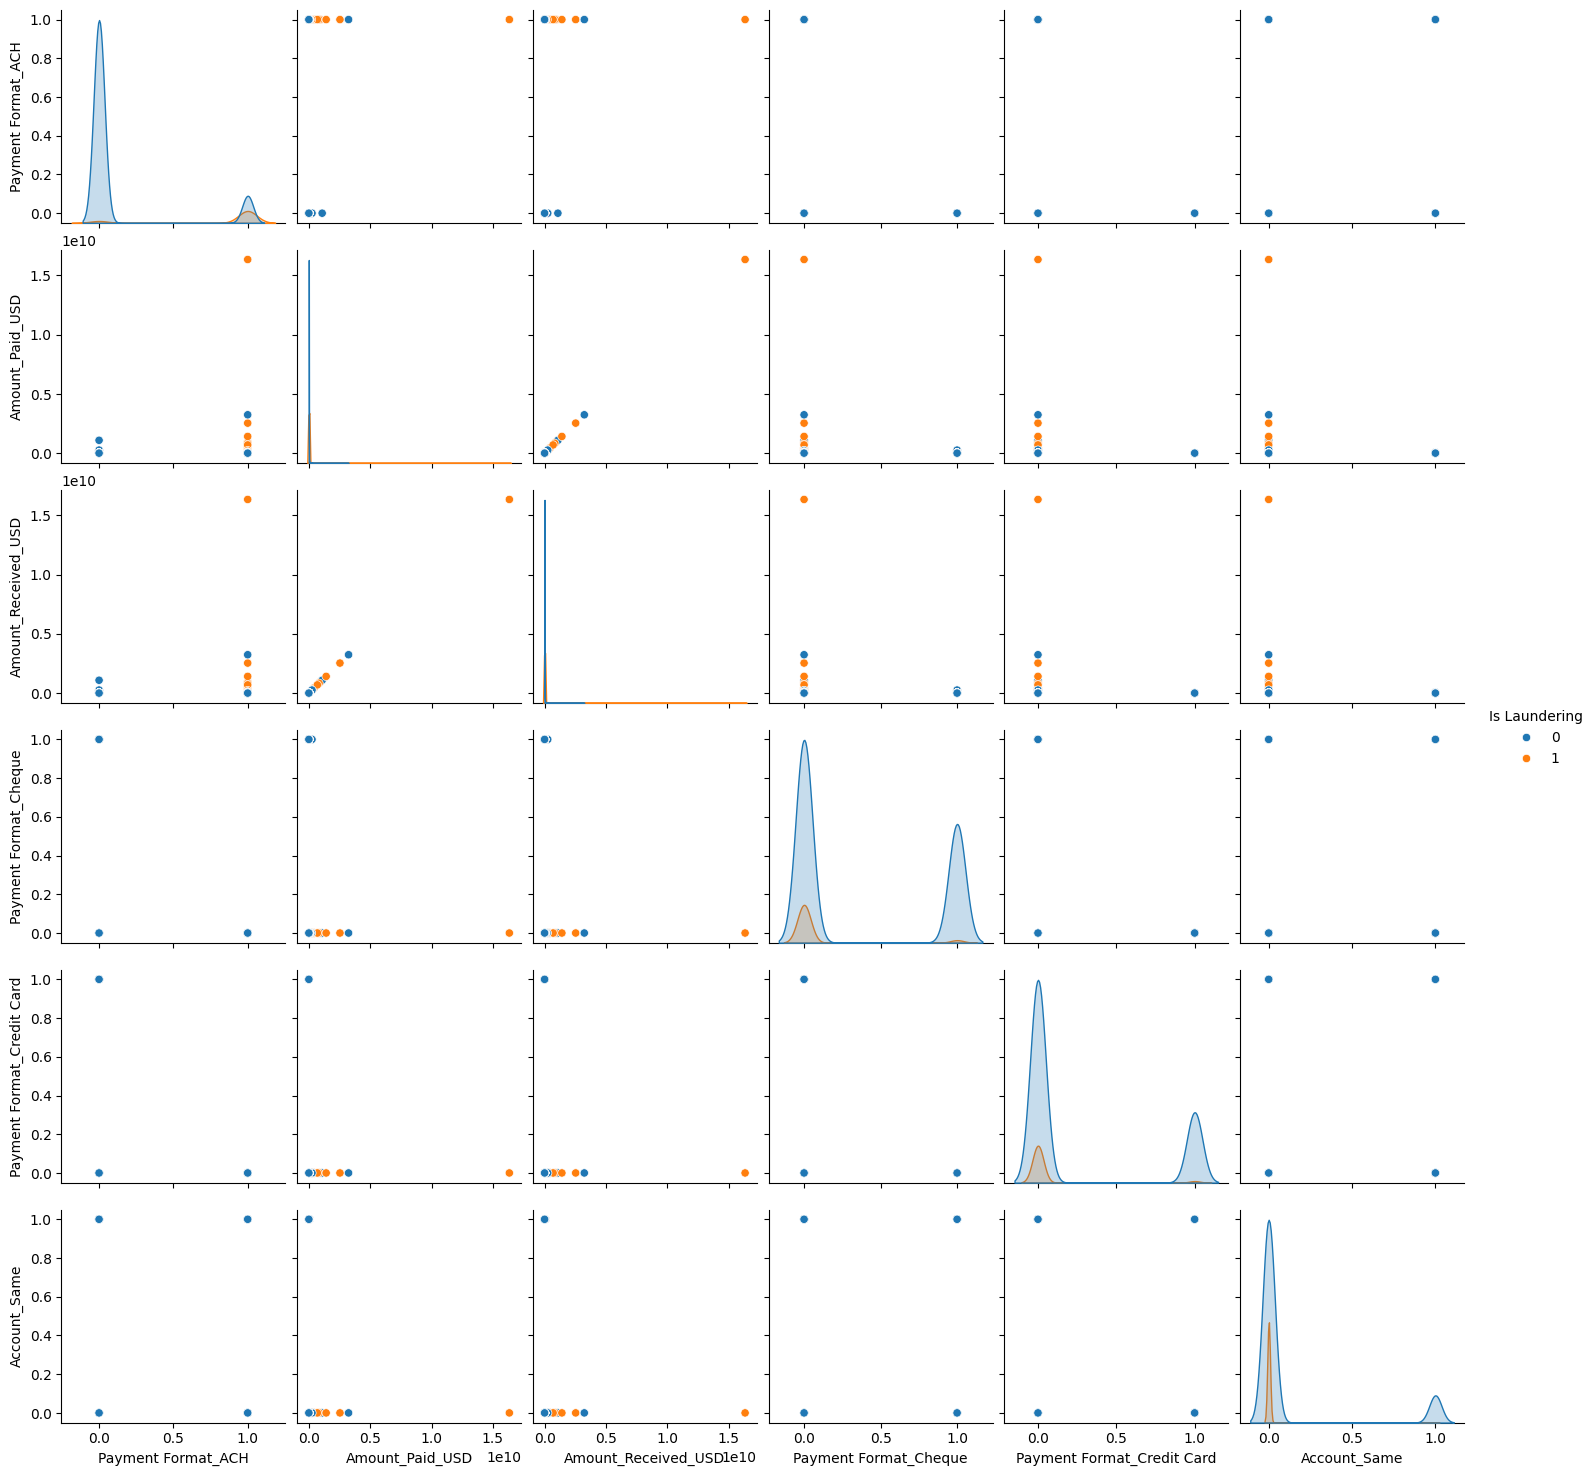

In [59]:
sns.pairplot(df_reduced[important_features + ['Is Laundering']], hue='Is Laundering')

Text(0.5, 1.0, 'Average Amount Paid by Bank Same and Account Same')

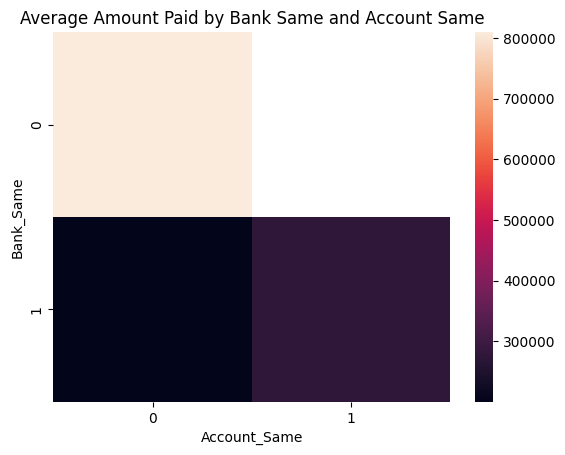

In [61]:
pivot2 = df_reduced.pivot_table(index = ["Bank_Same"], columns = ["Account_Same"], values = "Amount_Paid_USD", aggfunc = "mean") # note mean, not sum this time
ax2 = sns.heatmap(pivot2)
ax2.set_title("Average Amount Paid by Bank Same and Account Same")

Text(0.5, 1.0, 'Average Amount Paid by Bank Same and Account Same')

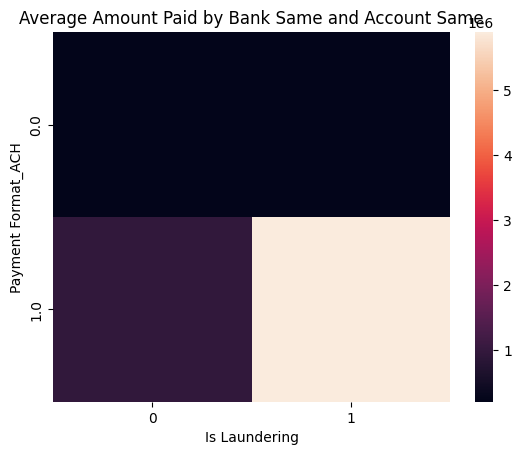

In [63]:
pivot2 = df_reduced.pivot_table(index = ["Payment Format_ACH"], columns = ["Is Laundering"], values = "Amount_Paid_USD", aggfunc = "mean") # note mean, not sum this time
ax2 = sns.heatmap(pivot2)
ax2.set_title("Average Amount Paid by Bank Same and Account Same")